# Taller: CNN aplicada al diagnóstico por imágenes — Clasificación de ecografías de mama (BreastMNIST)

Este taller construye, paso a paso, un flujo completo de clasificación de imágenes médicas con redes neuronales convolucionales (CNN): desde la exploración del dataset hasta un modelo con *transfer learning* interpretado con Grad-CAM y evaluado con curvas ROC y de calibración.

**Dataset: BreastMNIST**
- Contiene **780 ecografías de mama** en escala de grises (28×28 px), etiquetadas en 2 clases: `0 = malignant` (maligno) y `1 = normal, benign` (normal o benigno).
- Proviene del *Breast Ultrasound Images Dataset* (Al-Dhabyani et al., 2020), recolectado en el Hospital Baheya (Egipto) a 600 pacientes, con licencia abierta (Creative Commons).
- Fue estandarizado por **MedMNIST v2** (Yang et al., 2023, *Scientific Data*, Nature), un benchmark académico ampliamente citado, con partición oficial 70/10/20 (train/val/test) para evitar que nosotros mismos introduzcamos fugas de datos (*data leakage*).
- Se descarga de forma reproducible con `pip install medmnist`, sin scraping manual ni fuentes dudosas.

**Punto de partida importante:** con solo 780 imágenes en total (546 para entrenar), el riesgo de sobreajuste (*overfitting*) es alto. Por eso, cada etapa del taller incorpora explícitamente técnicas de regularización — BatchNorm, Dropout, weight decay, *scheduler* de learning rate, *early stopping* y aumento de datos moderado — y se cierra con una lectura crítica de qué tan confiables son realmente las predicciones del modelo.

Al final tendrás:
- Un modelo CNN entrenado desde cero, regularizado para un dataset pequeño.
- Un modelo con transfer learning (ResNet18) afinado en dos etapas.
- Evaluación con métricas clínicamente relevantes (accuracy, ROC-AUC, sensibilidad/especificidad, matriz de confusión).
- Grad-CAM para interpretar visualmente las decisiones del modelo.
- Curvas ROC y de calibración para juzgar qué tan confiables son las probabilidades predichas.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, filtros aprendibles que se deslizan por la imagen para detectar patrones. A continuación se nombran los conceptos junto con la función de PyTorch que los implementa (las mismas que se usan más adelante en el código):

### 1.1. Componentes clave

**(a) Convolución — `nn.Conv2d`**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Normalización por lotes — `nn.BatchNorm2d`**
- Normaliza las activaciones dentro de cada mini-lote.
- Estabiliza y acelera el entrenamiento, y actúa como un regularizador leve — muy útil cuando hay pocos datos, como en BreastMNIST.

**(c) Activación no lineal — `nn.ReLU`**
- Introduce no linealidad: `ReLU(x) = max(0, x)`.
- Permite que la red aprenda relaciones complejas, no solo combinaciones lineales de los píxeles.

**(d) Reducción espacial — `nn.MaxPool2d` / `nn.AdaptiveAvgPool2d`**
- Reduce la resolución espacial, conservando la información más relevante y disminuyendo el número de parámetros.

**(e) Regularización por apagado — `nn.Dropout`**
- Apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento, evitando que el modelo dependa de combinaciones específicas de ellas.

**(f) Clasificador final — `nn.Flatten` + `nn.Linear`**
- Aplana los mapas de características y los combina en una capa totalmente conectada para producir la predicción final.

> Con solo 780 imágenes en BreastMNIST, **BatchNorm y Dropout no son un detalle accesorio: son necesarios** para que el modelo generalice en lugar de memorizar el set de entrenamiento.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos, y `medmnist` para descargar el dataset de forma estandarizada y reproducible.


In [112]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",

    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (BreastMNIST)

Características del dataset:
- Entrada: ecografías de mama en escala de grises, tamaño 28x28.
- Etiquetas: clasificación binaria (`0 = malignant`, `1 = normal, benign`, según la definición oficial de MedMNIST).
- Particiones: train/val/test ya vienen definidas (70/10/20), evitando que nosotros mismos introduzcamos fugas de datos (data leakage).
- Tamaño total: 780 imágenes → **dataset pequeño**, hay que vigilar el overfitting de cerca en cada etapa.


In [113]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [114]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(546, 78, 156)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, contraste, ruido y variabilidad.


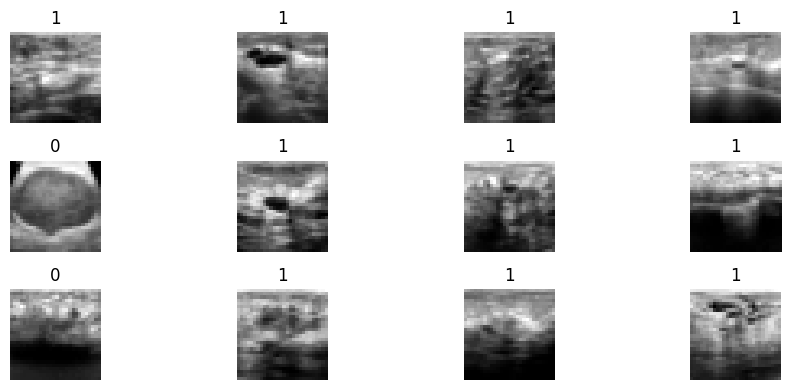

In [115]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


**Lectura de la muestra visualizada:** las 12 imágenes muestran la variabilidad típica de una ecografía real: contraste bajo, ruido tipo "grano" (*speckle*) propio del ultrasonido, y estructuras difusas sin bordes tan nítidos como en una foto natural. Esta es una de las razones por las que clasificar este tipo de imágenes es más difícil que clasificar fotos de objetos cotidianos, y por lo que la arquitectura necesita regularización para no aferrarse a detalles de ruido específicos de cada imagen en vez de patrones reales del tejido.


### 3.2. Revisar balance de clases

En datasets médicos pequeños es común que haya desbalance de clases, lo cual afecta cómo debemos interpretar el accuracy. Lo revisamos antes de entrenar.


In [116]:
import numpy as np

labels_train = np.array([int(train_dataset[i][1].item()) for i in range(len(train_dataset))])
unique, counts = np.unique(labels_train, return_counts=True)
dict(zip(unique.tolist(), counts.tolist()))


{0: 147, 1: 399}

**Lectura del balance de clases:** el set de entrenamiento tiene 147 imágenes de la clase `0` (malignant) y 399 de la clase `1` (normal/benign) — una proporción de aproximadamente 27% / 73%. Este desbalance es importante: un modelo que simplemente predijera siempre "normal/benigno" ya acertaría cerca del 73% de las veces sin haber aprendido nada útil. Por eso, más adelante, el accuracy se interpreta siempre junto con el ROC-AUC y la matriz de confusión, y no de forma aislada.


## 4. Preparar DataLoaders y device

Los **DataLoaders** (`torch.utils.data.DataLoader`) manejan el *batching* y el *shuffle* de los datos. El **device** nos permite usar GPU si está disponible.

Con solo 546 imágenes de entrenamiento, usamos `batch_size = 64`: esto significa menos de 9 lotes por época, lo cual reduce el ruido en las actualizaciones de gradiente frente a lotes muy pequeños, sin llegar a usar todo el set de una sola vez (lo que perdería el efecto regularizador del *mini-batch*).


In [117]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [118]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([64, 1, 28, 28]), torch.Size([64, 1]))

## 5. Modelo 1: CNN entrenada desde cero (con regularización)

Construimos una CNN básica pensada explícitamente para un dataset pequeño: cada bloque combina `Conv2d → BatchNorm2d → ReLU → MaxPool2d`, y se agrega `Dropout` antes del clasificador final (`Linear`). Sin esta regularización, una CNN con esta capacidad memoriza las ~546 imágenes de entrenamiento en pocas épocas y deja de generalizar.

Arquitectura resumida:
- 3 bloques convolucionales (16 → 32 → 64 filtros), cada uno con `BatchNorm2d` y `ReLU`.
- `AdaptiveAvgPool2d((1,1))` al final de las convoluciones, para no depender de un tamaño de entrada fijo.
- `Dropout(0.4)` justo antes de la capa `Linear` de salida.


In [119]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar más allá del accuracy:
- **Accuracy** (`accuracy_score`): porcentaje correcto global.
- **ROC-AUC** (`roc_auc_score`): capacidad de separar clases, independiente del umbral de decisión.
- **Matriz de confusión** (`confusion_matrix`): errores desagregados por clase.
- **Precision/Recall/F1** (`classification_report`): especialmente útiles cuando hay desbalance de clases, como en este dataset.

La función de pérdida usada es `nn.CrossEntropyLoss`, y las probabilidades se obtienen con `sigmoid`/`softmax` según la salida del modelo (`logits_to_probs`).


In [120]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    running_loss = 0.0
    criterion_eval = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion_eval(logits, y)
        running_loss += loss.item() * x.size(0)

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)

    val_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc, all_labels, all_preds, all_probs, val_loss


### 5.2. Entrenar el modelo desde cero (weight decay, scheduler y early stopping)

Tres mecanismos adicionales de regularización, además de BatchNorm y Dropout en la arquitectura:

- **Weight decay** (`weight_decay=1e-3` en `Adam`): regularización L2 sobre los pesos, que penaliza soluciones innecesariamente complejas.
- **Scheduler** (`ReduceLROnPlateau`, `factor=0.7`, `patience=7`): reduce el learning rate si el ROC-AUC de validación deja de mejorar.
- **Early stopping** (`patience_es=10`): nos quedamos con los pesos de la época donde el ROC-AUC de validación fue mejor, no con los de la última época — así evitamos quedarnos con un modelo ya sobreajustado.

Se usó además un **learning rate bajo (`1.5e-4`)**, deliberadamente conservador: con un set de validación de solo 78 imágenes, una tasa de aprendizaje más alta produce oscilaciones fuertes de una época a otra en las métricas de validación. Un LR bajo, combinado con mayor `weight_decay` y más paciencia en el *scheduler*, da una convergencia mucho más estable.


In [121]:
import copy

criterion = nn.CrossEntropyLoss()
# Opción con Learning Rate más bajo:
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1.5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.7, patience=7)

epochs = 50
patience_es = 10
best_auc = -1
best_state = None
epochs_no_improve = 0

history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader)
    scheduler.step(val_auc)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc + 1e-4:
        best_auc = val_auc
        best_state = copy.deepcopy(model_scratch.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc:.4f})")
        break

model_scratch.load_state_dict(best_state)


Epoch 01 | train_loss=0.6249 | val_loss=0.7156 | val_acc=0.2692 | val_auc=0.5597
Epoch 02 | train_loss=0.6145 | val_loss=0.7090 | val_acc=0.3077 | val_auc=0.6015
Epoch 03 | train_loss=0.5851 | val_loss=0.6814 | val_acc=0.6410 | val_auc=0.6558
Epoch 04 | train_loss=0.5629 | val_loss=0.6538 | val_acc=0.6795 | val_auc=0.7260
Epoch 05 | train_loss=0.5431 | val_loss=0.6200 | val_acc=0.7308 | val_auc=0.7619
Epoch 06 | train_loss=0.5289 | val_loss=0.5710 | val_acc=0.7308 | val_auc=0.7602
Epoch 07 | train_loss=0.5164 | val_loss=0.5271 | val_acc=0.7436 | val_auc=0.7561
Epoch 08 | train_loss=0.5191 | val_loss=0.5073 | val_acc=0.7692 | val_auc=0.7728
Epoch 09 | train_loss=0.4959 | val_loss=0.4910 | val_acc=0.7692 | val_auc=0.7937
Epoch 10 | train_loss=0.4948 | val_loss=0.4838 | val_acc=0.7692 | val_auc=0.7903
Epoch 11 | train_loss=0.4811 | val_loss=0.4775 | val_acc=0.7949 | val_auc=0.7970
Epoch 12 | train_loss=0.4780 | val_loss=0.4738 | val_acc=0.7821 | val_auc=0.7903
Epoch 13 | train_loss=0.4764

<All keys matched successfully>

### 5.3. Curvas de entrenamiento

Visualizamos **pérdida de entrenamiento vs. validación** para detectar sobreajuste directamente: si la pérdida de entrenamiento sigue bajando mientras la de validación sube (o se separan cada vez más), es la señal clásica de overfitting.


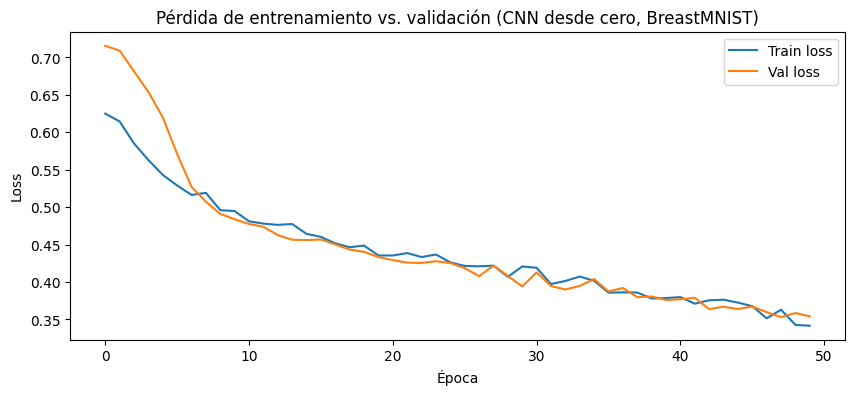

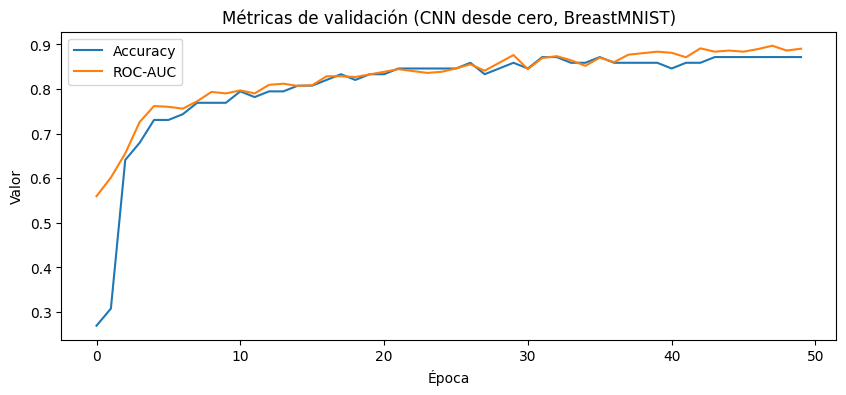

In [122]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train loss")
plt.plot(history_scratch["val_loss"], label="Val loss")
plt.title("Pérdida de entrenamiento vs. validación (CNN desde cero, BreastMNIST)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero, BreastMNIST)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


**Lectura de las curvas de entrenamiento:** la pérdida de entrenamiento y de validación bajan juntas durante las 50 épocas y terminan muy cerca una de otra (≈0.34 vs. ≈0.35), sin el "abanico" que indicaría sobreajuste. El ROC-AUC de validación sube de forma prácticamente monótona desde 0.56 (equivalente a azar) hasta cerca de 0.89–0.90, sin las oscilaciones bruscas que aparecerían con un learning rate más alto. Esto confirma que el learning rate bajo, el weight decay y la paciencia del *scheduler* lograron el objetivo: una convergencia estable y sin overfitting visible en el modelo entrenado desde cero.


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización real.


In [123]:
test_acc, test_auc, y_true, y_pred, y_prob, test_loss = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8333
Test ROC-AUC:  0.8567

              precision    recall  f1-score   support

           0     0.7857    0.5238    0.6286        42
           1     0.8438    0.9474    0.8926       114

    accuracy                         0.8333       156
   macro avg     0.8147    0.7356    0.7606       156
weighted avg     0.8281    0.8333    0.8215       156



array([[ 22,  20],
       [  6, 108]])

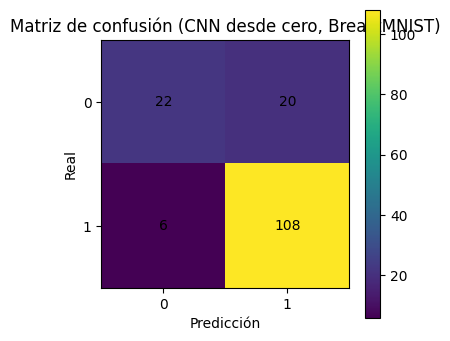

In [124]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero, BreastMNIST)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


**Lectura de los resultados en test:** el modelo alcanza **83.3% de accuracy** y **0.857 de ROC-AUC**. La matriz de confusión, sin embargo, revela una asimetría relevante: de las 42 imágenes malignas (clase `0`) del set de prueba, solo 22 fueron detectadas correctamente (*recall* = 52.4%), mientras que de las 114 imágenes normales/benignas (clase `1`), 108 fueron bien clasificadas (*recall* = 94.7%). Es decir, el modelo es mucho más confiable descartando enfermedad que detectándola — un patrón esperable dado el desbalance de clases (147 vs. 399 en entrenamiento), pero que en un escenario clínico real necesitaría corregirse antes de confiar en el modelo.


## 6. Data Augmentation (aumento de datos)

Con solo ~546 imágenes de entrenamiento, el aumento de datos es una estrategia razonable para intentar mejorar la generalización en BreastMNIST. En ecografías hay que tener cuidado con qué transformaciones se aplican:
- Rotaciones pequeñas y traslaciones suaves son razonables (el paciente puede estar ligeramente distinto en cada toma).
- Flips horizontales suelen ser aceptables en ecografía de mama (no hay una orientación anatómica fija como en una radiografía de tórax).
- Se evitan distorsiones fuertes que puedan alterar estructuras clínicamente relevantes.

Entrenamos un modelo con el mismo diseño (misma arquitectura regularizada) para comparar contra el modelo sin aumento.


In [125]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [126]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 25
patience_es = 6
best_auc_aug = -1
best_state_aug = None
epochs_no_improve = 0

history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_aug, val_loader)
    scheduler.step(val_auc)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_aug:
        best_auc_aug = val_auc
        best_state_aug = copy.deepcopy(model_aug.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc_aug:.4f})")
        break

model_aug.load_state_dict(best_state_aug)


Epoch 01 | train_loss=0.6032 | val_loss=0.6413 | val_acc=0.7308 | val_auc=0.6358
Epoch 02 | train_loss=0.5354 | val_loss=0.6615 | val_acc=0.7308 | val_auc=0.7419
Epoch 03 | train_loss=0.5162 | val_loss=0.6611 | val_acc=0.7308 | val_auc=0.7519
Epoch 04 | train_loss=0.4928 | val_loss=0.6279 | val_acc=0.7949 | val_auc=0.8087
Epoch 05 | train_loss=0.4864 | val_loss=0.5319 | val_acc=0.7949 | val_auc=0.8204
Epoch 06 | train_loss=0.4750 | val_loss=0.5383 | val_acc=0.7949 | val_auc=0.8655
Epoch 07 | train_loss=0.4683 | val_loss=0.4619 | val_acc=0.8205 | val_auc=0.8897
Epoch 08 | train_loss=0.4463 | val_loss=0.4547 | val_acc=0.7692 | val_auc=0.8488
Epoch 09 | train_loss=0.4562 | val_loss=0.4060 | val_acc=0.8205 | val_auc=0.8981
Epoch 10 | train_loss=0.4516 | val_loss=0.3987 | val_acc=0.8462 | val_auc=0.8822
Epoch 11 | train_loss=0.4285 | val_loss=0.3866 | val_acc=0.8718 | val_auc=0.8906
Epoch 12 | train_loss=0.4242 | val_loss=0.3982 | val_acc=0.8333 | val_auc=0.8772
Epoch 13 | train_loss=0.4182

<All keys matched successfully>

### 6.1. Comparación rápida


In [127]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8333 | test_auc=0.8567
Con augmentation  | test_acc=0.7949 | test_auc=0.8544


**Lectura de la comparación con/sin aumento de datos:** en este entrenamiento, el aumento de datos **no mejoró** el resultado (accuracy 79.5% y AUC 0.854, frente a 83.3% y 0.857 sin aumento). Con un dataset tan pequeño (546 imágenes), rotaciones y traslaciones aleatorias pueden introducir suficiente variabilidad como para dificultar el aprendizaje en pocas épocas, en vez de ayudar a generalizar — el beneficio del aumento de datos no es automático y depende de cuánta información nueva realmente aporta frente al ruido que introduce.


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (ImageNet) y adaptarlo a nuestra tarea. Es especialmente valioso aquí porque **BreastMNIST solo tiene 780 imágenes** — entrenar una red profunda desde cero con tan pocos datos es mucho más propenso a overfitting que aprovechar características ya aprendidas.

Ventajas:
- Converge más rápido.
- Suele mejorar el rendimiento con pocos datos, que es exactamente nuestro caso.

Desafíos en imágenes médicas:
- Las ecografías son en escala de grises (ImageNet es en color).
- El dominio (ultrasonido) es distinto a fotos naturales, por lo que las características preentrenadas transfieren solo parcialmente.

Estrategia de entrenamiento en dos etapas:
1. Congelar el backbone y agregar **Dropout** antes de la capa final; entrenar solo la última capa (`fc`).
2. Descongelar únicamente `layer4` para un *fine-tuning* con un learning rate bajo.


In [128]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet (`torchvision.models.resnet18`).

Estrategia de congelamiento:
- Se congelan todos los parámetros del backbone (`requires_grad = False`).
- Se reemplaza `resnet.fc` por `Dropout(0.4) + Linear`, y solo esa capa queda entrenable en la primera etapa.


In [129]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [130]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 10
best_auc_tl1 = -1
best_state_tl1 = None

history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)
    scheduler.step(val_auc)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_tl1:
        best_auc_tl1 = val_auc
        best_state_tl1 = copy.deepcopy(resnet.state_dict())

resnet.load_state_dict(best_state_tl1)


Stage1 Epoch 01 | train_loss=0.6371 | val_loss=0.6575 | val_acc=0.6923 | val_auc=0.3718
Stage1 Epoch 02 | train_loss=0.5919 | val_loss=0.6383 | val_acc=0.7051 | val_auc=0.3651
Stage1 Epoch 03 | train_loss=0.5812 | val_loss=0.5929 | val_acc=0.7308 | val_auc=0.5246
Stage1 Epoch 04 | train_loss=0.5666 | val_loss=0.5555 | val_acc=0.7308 | val_auc=0.6533
Stage1 Epoch 05 | train_loss=0.5557 | val_loss=0.5433 | val_acc=0.7308 | val_auc=0.7243
Stage1 Epoch 06 | train_loss=0.5479 | val_loss=0.5149 | val_acc=0.7692 | val_auc=0.7043
Stage1 Epoch 07 | train_loss=0.5236 | val_loss=0.5216 | val_acc=0.7692 | val_auc=0.6867
Stage1 Epoch 08 | train_loss=0.5374 | val_loss=0.5176 | val_acc=0.7564 | val_auc=0.7043
Stage1 Epoch 09 | train_loss=0.5299 | val_loss=0.4988 | val_acc=0.7564 | val_auc=0.7393
Stage1 Epoch 10 | train_loss=0.5091 | val_loss=0.4867 | val_acc=0.7564 | val_auc=0.7536


<All keys matched successfully>

**Lectura de la etapa de calentamiento (solo `fc` entrenable):** durante las primeras épocas el ROC-AUC de validación arranca muy bajo (0.37) — incluso peor que azar — y solo hacia la época 5 empieza a superar 0.70. Esto es esperable: con el backbone completamente congelado, el modelo apenas está ajustando una capa lineal sobre características pensadas originalmente para fotografías de ImageNet, no para ecografías en escala de grises. Esta etapa sirve principalmente para inicializar razonablemente la nueva capa `fc` antes de permitir que `layer4` se adapte al dominio médico.


### 7.2. Fine-tuning (descongelar capas)

Descongelamos solo `layer4` (y la nueva `fc`), usando un learning rate más bajo (`1e-4`) que en la etapa 1 para no destruir lo ya aprendido en ImageNet — esto es clave con pocos datos, ya que descongelar todo el backbone con solo ~546 imágenes llevaría a overfitting casi de inmediato.


In [131]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [132]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

epochs = 10
patience_es = 4
best_auc_tl2 = -1
best_state_tl2 = None
epochs_no_improve = 0

history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)
    scheduler.step(val_auc)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_auc_tl2:
        best_auc_tl2 = val_auc
        best_state_tl2 = copy.deepcopy(resnet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
        print(f"Early stopping en la época {epoch} (mejor val_auc={best_auc_tl2:.4f})")
        break

resnet.load_state_dict(best_state_tl2)


Stage2 Epoch 01 | train_loss=0.4974 | val_loss=0.4243 | val_acc=0.7949 | val_auc=0.8354
Stage2 Epoch 02 | train_loss=0.3802 | val_loss=0.4070 | val_acc=0.8077 | val_auc=0.8638
Stage2 Epoch 03 | train_loss=0.3483 | val_loss=0.3905 | val_acc=0.8205 | val_auc=0.8713
Stage2 Epoch 04 | train_loss=0.3280 | val_loss=0.3890 | val_acc=0.8590 | val_auc=0.8839
Stage2 Epoch 05 | train_loss=0.2852 | val_loss=0.3624 | val_acc=0.8718 | val_auc=0.9148
Stage2 Epoch 06 | train_loss=0.2402 | val_loss=0.3417 | val_acc=0.8718 | val_auc=0.9282
Stage2 Epoch 07 | train_loss=0.1946 | val_loss=0.4100 | val_acc=0.8590 | val_auc=0.9340
Stage2 Epoch 08 | train_loss=0.2045 | val_loss=0.3370 | val_acc=0.8846 | val_auc=0.9357
Stage2 Epoch 09 | train_loss=0.1662 | val_loss=0.3027 | val_acc=0.8974 | val_auc=0.9265
Stage2 Epoch 10 | train_loss=0.1489 | val_loss=0.3088 | val_acc=0.8974 | val_auc=0.9348


<All keys matched successfully>

**Lectura del fine-tuning:** al descongelar `layer4`, el ROC-AUC de validación mejora rápidamente hasta 0.936 (época 8) y el train_loss cae de 0.50 a 0.15. Aquí aparece una señal a vigilar: hacia el final, el train_loss (≈0.15) queda claramente por debajo del val_loss (≈0.31), lo cual es el inicio de un sobreajuste típico al descongelar capas de una red grande con pocos datos. La razón por la que esto no perjudica el resultado final es que el modelo guardado **no es el de la última época**, sino el de la época con mejor ROC-AUC de validación (early stopping por métrica, no por época fija).


### 7.3. Evaluación en test del modelo con transfer learning


In [133]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8526 | test_auc=0.8741

              precision    recall  f1-score   support

           0     0.8800    0.5238    0.6567        42
           1     0.8473    0.9737    0.9061       114

    accuracy                         0.8526       156
   macro avg     0.8637    0.7487    0.7814       156
weighted avg     0.8561    0.8526    0.8390       156



array([[ 22,  20],
       [  3, 111]])

**Lectura de los resultados en test con transfer learning:** accuracy 85.3% y ROC-AUC 0.874 — una mejora clara sobre la CNN entrenada desde cero en ambas métricas. Sin embargo, la limitación persiste: el *recall* de la clase maligna sigue en 52.4% (22 de 42 casos), igual que en el modelo anterior, mientras que el *recall* de la clase normal/benigna sube a 97.4%. Es decir, transfer learning mejoró la calidad general de las probabilidades (por eso sube el AUC), pero **no resolvió** el problema de fondo del desbalance de clases con el umbral de decisión por defecto (0.5).


### 7.4. Comparación global (resumen)


In [134]:
print("Resumen de resultados en test (BreastMNIST)")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test (BreastMNIST)
CNN desde cero (sin aug)   | acc=0.8333 | auc=0.8567
CNN desde cero (con aug)   | acc=0.7949 | auc=0.8544
Transfer learning (ResNet) | acc=0.8526 | auc=0.8741


**Lectura de la comparación global:** de los tres modelos entrenados, el de transfer learning es el mejor tanto en accuracy (85.3%) como en ROC-AUC (0.874). La CNN desde cero sin aumento queda en segundo lugar (83.3% / 0.857), y la versión con aumento de datos queda última en accuracy (79.5%) aunque con un AUC casi idéntico (0.854) — coherente con la lectura anterior de que el aumento de datos no aportó valor en este caso concreto.


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es tan importante como el resultado mismo.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando las regiones que más influyeron en la predicción. Aquí se implementa registrando *hooks* sobre `layer4` de ResNet18 para capturar activaciones y gradientes.


In [135]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    model.zero_grad()
    logits[0, target_class].backward()

    acts = activations["value"][0]
    grads = gradients["value"][0]
    weights = grads.mean(dim=(1, 2))

    cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.detach().cpu().numpy()

    handle_fwd.remove()
    handle_bwd.remove()

    return cam, target_class


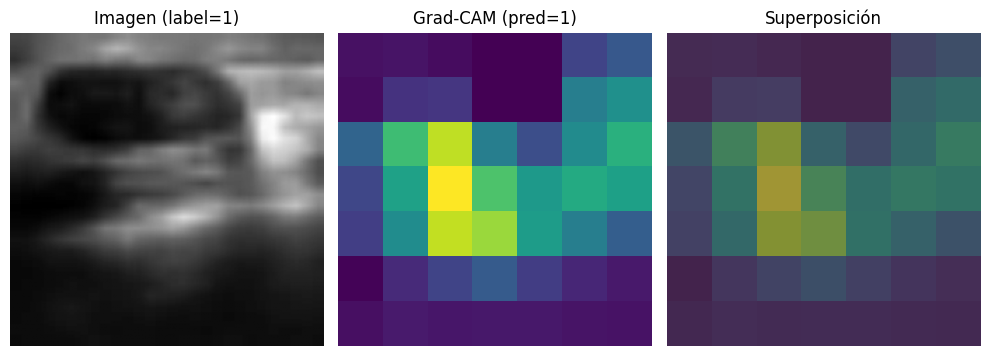

In [141]:
idx = 1
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


**Lectura del Grad-CAM:** para este caso (`label=1`, correctamente predicho como `1`), el mapa de calor se concentra en una región central-izquierda de la imagen, coincidiendo con la zona de mayor variación de intensidad (el área más oscura/definida de la ecografía) en lugar de con el fondo homogéneo. Esto es una señal razonable de que el modelo está mirando la estructura relevante y no un artefacto del borde de la imagen. Una limitación a tener en cuenta: como `layer4` de ResNet18 produce un mapa de activaciones de muy baja resolución (7×7) para una imagen ya de por sí pequeña (28×28 reescalada a 224×224), el Grad-CAM resultante es necesariamente "pixelado" — útil como indicio, no como una segmentación precisa.


## 9. Curvas ROC y calibración de probabilidades

Además del ROC-AUC (un solo número resumen), es importante **visualizar la curva ROC completa** (`roc_curve`) y revisar si las probabilidades que da el modelo están **bien calibradas** (`calibration_curve`): que una probabilidad de 0.8 realmente signifique "80% de las veces es positivo", y no solo un número arbitrario que separa bien las clases pero está mal calibrado.


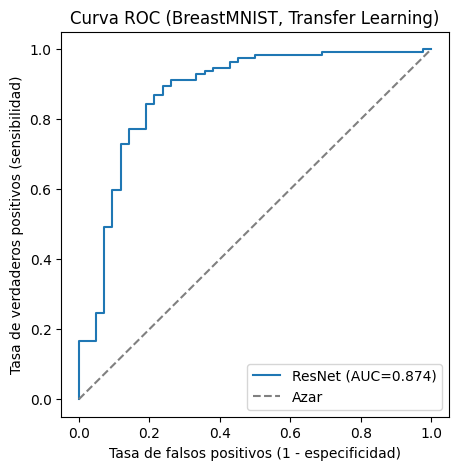

In [137]:
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fpr, tpr, _ = roc_curve(y_true_tl, y_prob_tl)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ResNet (AUC={test_auc_tl:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC (BreastMNIST, Transfer Learning)")
plt.legend()
plt.show()


**Lectura de la curva ROC:** con AUC=0.874, la curva sube muy rápido en la zona de baja tasa de falsos positivos (con FPR≈0.1 ya se alcanza un TPR cercano a 0.6–0.7), lo cual indica que existe un rango de umbrales donde el modelo logra una sensibilidad razonable sin disparar los falsos positivos. Esto es justamente la palanca pendiente de usar: en vez del umbral por defecto (0.5), se podría elegir un punto de esta curva con mayor sensibilidad (mejor detección de casos malignos) asumiendo algunos falsos positivos adicionales — una decisión que en salud casi siempre conviene sesgar hacia mayor sensibilidad.


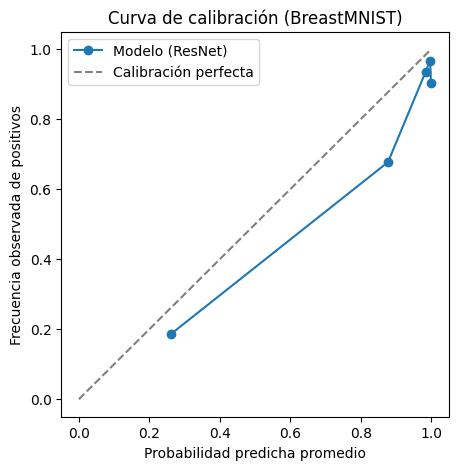

In [138]:
prob_true, prob_pred = calibration_curve(y_true_tl, y_prob_tl, n_bins=5, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (ResNet)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha promedio")
plt.ylabel("Frecuencia observada de positivos")
plt.title("Curva de calibración (BreastMNIST)")
plt.legend()
plt.show()


**Cómo interpretar la curva de calibración obtenida:** para probabilidades predichas bajas (~0.25) el modelo está razonablemente calibrado (frecuencia observada cercana a la predicha), pero para probabilidades medias y altas (~0.87 y ~0.99) la frecuencia observada real queda por **debajo** de la predicha — el modelo tiende a estar **sobre-confiado** en esa zona. Esto es un patrón común en modelos entrenados con pocos datos y evaluados sobre un set de validación pequeño (78 imágenes, muy pocas por *bin* de calibración). En un uso clínico real, esto justificaría aplicar una técnica de recalibración (por ejemplo, *temperature scaling*) antes de usar las probabilidades como apoyo a una decisión.


## 10. Buenas prácticas (especialmente en salud)

1. **Separación estricta** de train/val/test para evitar data leakage — se usa siempre el split oficial de MedMNIST.

2. Reportar métricas más allá del accuracy:
   - **Recall (sensibilidad)**: qué tanto detectas casos malignos reales.
   - **Especificidad**: qué tanto evitas falsos positivos.
   - **ROC-AUC**: separación global entre clases.
   - **Calibración**: qué tan confiables son las probabilidades, no solo la clase final.

3. Cuidado con sesgos:
   - Diferencias por equipo de ultrasonido, hospital, población de pacientes.
   - Etiquetas ruidosas o revisadas por un solo especialista.

4. Con datasets pequeños (como BreastMNIST, 780 imágenes) el overfitting es el riesgo principal:
   - Arquitectura regularizada (BatchNorm + Dropout).
   - Weight decay y scheduler de learning rate.
   - Early stopping basado en la métrica de validación (no en la última época).
   - Data augmentation moderado y clínicamente razonable.
   - Preferir transfer learning sobre entrenar una red profunda desde cero.

5. Validación externa:
   - Probar en datos de otra fuente/hospital es clave antes de cualquier uso real.

6. Interpretabilidad:
   - Grad-CAM es útil para inspeccionar el modelo, pero **no prueba causalidad** ni reemplaza el criterio médico.

7. Reproducibilidad:
   - Fijar semillas (seeds), registrar versiones de librerías y guardar los pesos del mejor modelo (no del último).


## 11. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones, sin tener que reentrenar desde cero.


In [139]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch_breastmnist.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug_breastmnist.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer_breastmnist.pth")

["models/cnn_scratch_breastmnist.pth", "models/cnn_aug_breastmnist.pth", "models/resnet_transfer_breastmnist.pth"]


['models/cnn_scratch_breastmnist.pth',
 'models/cnn_aug_breastmnist.pth',
 'models/resnet_transfer_breastmnist.pth']

## 12. Conclusiones

Con un dataset de solo 780 imágenes, el mayor riesgo no era que el modelo no aprendiera, sino que **memorizara** el set de entrenamiento. Las decisiones tomadas en este taller, todas orientadas a lo mismo, fueron:

| Técnica | Dónde se aplicó | Qué evita |
|---|---|---|
| BatchNorm | Arquitectura `SimpleCNN` | Activaciones inestables, ligera regularización |
| Dropout | `SimpleCNN` y capa `fc` de ResNet | Dependencia de neuronas específicas |
| Weight decay (L2) | Todos los optimizadores Adam | Pesos demasiado grandes / complejidad excesiva |
| Learning rate bajo | Entrenamiento del modelo desde cero | Oscilaciones fuertes entre épocas por el pequeño set de validación |
| Data augmentation moderado | Sección 6 y transfer learning | Memorización de imágenes exactas |
| Early stopping por `val_auc` | Todos los entrenamientos | Quedarse con un modelo ya sobreajustado |
| Fine-tuning parcial (solo `layer4`) | Sección 7.2 | Destruir el conocimiento preentrenado con pocos datos |
| Curvas train vs. val loss | Sección 5.3 | Detectar overfitting visualmente en tiempo real |
| ROC-AUC + calibración (no solo accuracy) | Secciones 5–9 | Confiar en una métrica engañosa por desbalance de clases |

**Resultado final:** el modelo con transfer learning (ResNet18) fue el mejor de los tres (test accuracy 0.853, ROC-AUC 0.874), superando a la CNN entrenada desde cero (accuracy 0.833, AUC 0.857) y confirmando el valor de reutilizar características preentrenadas cuando el dataset propio es pequeño.

**Limitación importante a resolver a futuro:** en los tres modelos, el *recall* de la clase minoritaria (`0 = malignant`) se mantuvo alrededor de 52% — es decir, casi la mitad de los casos malignos del set de prueba fueron clasificados como normales/benignos. En un contexto clínico real esto es más grave que un error simétrico, porque un falso negativo puede retrasar un diagnóstico. Antes de cualquier uso real habría que atacar directamente este punto: ponderar la función de pérdida por clase (*class weighting*), ajustar el umbral de decisión (en vez de usar 0.5 por defecto) priorizando sensibilidad, o conseguir más ejemplos de la clase maligna.
